# Lab 1 - Entrenamiento de redes neuronales

## 1. Dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Tensorflow
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import MeanSquaredError, RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error


#Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import kagglehub
import shutil
import os

In [27]:
destino = "/Users/Camila/Desktop"

# Descargar al caché de KaggleHub
path = kagglehub.dataset_download("camnugent/california-housing-prices")

# Crear la carpeta si no existe
os.makedirs(destino, exist_ok=True)

# Copiar los archivos
shutil.copytree(path, destino, dirs_exist_ok=True)

print(f"Dataset copiado a: {destino}")

Dataset copiado a: /Users/Camila/Desktop


## 2. Exploración de los datos

In [28]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### ¿Cuántas observaciones y cuántas variables tiene el dataset?

In [29]:
print(df.shape)

(20640, 10)


El dataset contiene 20,640 observaciones y 10 variables.

### ¿Qué representa cada variable (feature) y cuál es la variable objetivo (target)?

In [30]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

longitude - Longitud de la vivienda. latitude - Latitud de la vivienda. housing_median_age - Edad mediana de las viviendas. total_rooms	Número - total de habitaciones. total_bedrooms - Número total de dormitorios. population - Población del bloque censal. households - Número de hogares. median_income - Ingreso mediano de los hogares. ocean_proximity - Cercanía al océano (variable categórica). median_house_value - Valor mediano de las viviendas.

La variable objetivo es median_house_value.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### ¿Hay valores nulos, duplicados o atípicos (outliers)? ¿Cómo los trató?

In [32]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [33]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

Se encontraron 207 valores nulos en la variable total_bedrooms, fueron reemplazados usando la mediana de la columna.

In [34]:
df.duplicated().sum()

np.int64(0)

No se encontraron registros duplicados

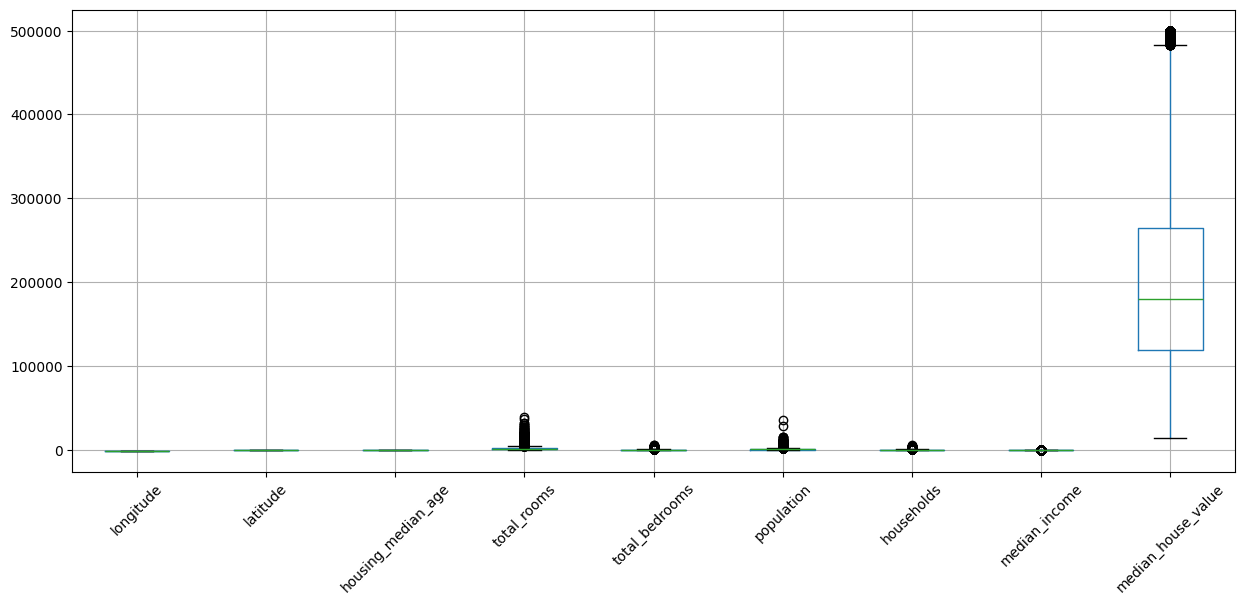

In [35]:
df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

Usando boxplots se identificaron valores atípicos en las variables total_rooms, total_bedrooms, population, households y median_house_value. Sin embargo, estos valores representan observaciones reales, por lo que se decidió conservarlos para no perder información relevante del conjunto de datos.

### ¿Qué variables son numéricas y cuáles categóricas? ¿Cómo codificó las categóricas?

In [36]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Todas las variables son numéricas, exepto ocean_proximity.

In [37]:
df = pd.get_dummies(df,
                    columns=["ocean_proximity"],
                    drop_first=True)

Como los algoritmos de aprendizaje automático trabajan con datos numéricos, esta variable fue transformada mediante One-Hot Encoding. Además, se usó el parámetro drop_first=True para eliminar una de las categorías y evitar problemas de multicolinealidad.

### ¿Fue necesario normalizar o escalar las variables numéricas?

Se decidió estandarizar las variables numéricas con StandardScaler, porque las variables del conjunto de datos presentan escalas muy diferentes. Si no se escalan, las variables con valores más grandes dominan el proceso de aprendizaje de la red, afectando el desempeño del modelo.

## 3. Investigación

### nn.Linear

Implementa una transformación lineal entre una capa y la siguiente. Cada neurona recibe todas las salidas de la capa anterior y calcula una combinación lineal de ellas, aprendiendo un conjunto de pesos y un sesgo durante el entrenamiento. Es la capa fundamental para construir un perceptrón multicapa.

Parámetros principales:

in_features: número de características de entrada.
out_features: número de neuronas de salida.
bias: indica si la capa utiliza un sesgo, es True por defecto.

### Funciones de activación

Las funciones de activación introducen no linealidad en la red, permitiendo que el modelo aprenda relaciones complejas entre las variables.

#### nn.ReLU

Devuelve el valor de entrada cuando es positivo y cero cuando es negativo.

Ventajas: rápida computacionalmente, reduce el problema del gradiente desvanecido, es la función de activación más utilizada en redes neuronales profundas.

#### nn.LeakyReLU

Es una variante de ReLU que permite un pequeño gradiente cuando la entrada es negativa.
	​
Ventajas: evita que algunas neuronas dejen de aprender, mantiene un pequeño flujo de gradiente para valores negativos.

#### nn.Tanh

La función tangente hiperbólica transforma los datos al intervalo: [−1,1]

Ventajas: produce salidas centradas en cero, funciona bien cuando los datos fueron estandarizados.

Desventaja: en redes profundas puede sufrir el problema del gradiente desvanecido.

### nn.Dropout

Técnica de regularización que durante el entrenamiento desactiva aleatoriamente un porcentaje de neuronas. Busca evitar que la red memorice los datos de entrenamiento y mejorar la capacidad de generalización.

Parámetro principal:

p: probabilidad de desactivar una neurona.

### nn.BatchNorm1d

Normaliza las activaciones de cada mini-batch durante el entrenamiento. Esto permite acelerar la convergencia, estabilizar el entrenamiento, permitir tasas de aprendizaje más altas y reducir el sobreajuste.

Parámetro principal:

num_features: número de características de entrada que serán normalizadas.

### funciones de pérdida de regresión

Mide qué tan lejos están las predicciones del modelo respecto a los valores reales.

#### nn.MSELoss

Calcula el Error Cuadrático Medio (Mean Squared Error). Penaliza fuertemente los errores grandes, es la función más utilizada en problemas de regresión.

#### nn.L1Loss

Calcula el Error Absoluto Medio (Mean Absolute Error). Es más robusta frente a valores atípicos, todos los errores tienen el mismo peso.

#### nn.SmoothL1Loss

Combina las ventajas de MSE y MAE, porque para errores pequeños se comporta como MSE y para errores grandes se comporta como MAE. Tiene menor sensibilidad a los outliers y hace que el entrenamiento sea más estable.

### Optimizadores

Actualizan los pesos de la red usando el gradiente calculado durante backpropagation. Buscan minimizar la función de pérdida para que el modelo aprenda la relación entre las variables de entrada y la variable objetivo.

Parámetros importantes: 

lr (learning rate): Es la tasa de aprendizaje, determina el tamaño de los pasos que el optimizador da al actualizar los pesos (si es muy grande, el entrenamiento puede volverse inestable y no converger y si es muy pequeña, el entrenamiento es muy lento)

weight_decay: Aplica regularización L2. Busca penalizar pesos muy grandes para reducir el sobreajuste y mejorar la capacidad de generalización.

#### SGD (Stochastic Gradient Descent)

Actualiza los pesos utilizando el gradiente calculado en cada iteración.

Es el optimizador más simple, cConsume poca memoria, puede tardar más en converger y requiere elegir cuidadosamente el learning rate.

#### Adam (Adaptive Moment Estimation) 

Adapta automáticamente la tasa de aprendizaje para cada parámetro usando estimaciones del primer y segundo momento del gradiente.

Converge rápidamente, requiere poca afinación de hiperparámetros, es uno de los optimizadores más usados en redes neuronales.

#### RMSprop

Ajusta la tasa de aprendizaje de cada parámetro con el promedio móvil de los gradientes recientes.

Funciona bien cuando los gradientes cambian constantemente, es más estable que SGD y generalmente converge más rápido que SGD, aunque es superado por Adam en muchas aplicaciones.

## 4. Entrenamiento e iteración de parámetros

In [38]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

In [39]:
from sklearn.model_selection import train_test_split 

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [40]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (16512, 12)
Validation: (2064, 12)
Test: (2064, 12)


In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

### Convertimos los datos a tensors

In [42]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [43]:
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [44]:
print(X_train.shape)
print(y_train.shape)

torch.Size([16512, 12])
torch.Size([16512, 1])


### Creación de DataLoaders

In [45]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

In [46]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

### Definir grid

In [48]:
from itertools import product

param_grid = {
    "hidden_layers": [
        [64, 32],
        [128, 64]
    ],

    "activation": [
        "relu",
        "leakyrelu"
    ],

    "optimizer": [
        "adam",
        "rmsprop"
    ],

    "lr": [
        0.001
    ],

    "batch_size": [
        64
    ],

    "epochs": [
        100
    ],

    "dropout": [
        0.2
    ],

    "weight_decay": [
        0,
        0.001
    ]
}

In [49]:
keys = param_grid.keys()

values = param_grid.values()

configs = [
    dict(zip(keys, v))
    for v in product(*values)
]

In [50]:
print(len(configs))

16


In [51]:
configs = configs[:10]

print(len(configs))

10


In [52]:
for i, config in enumerate(configs, start=1):
    print(f"Modelo {i}")
    print(config)
    print("-" * 50)

Modelo 1
{'hidden_layers': [64, 32], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 100, 'dropout': 0.2, 'weight_decay': 0}
--------------------------------------------------
Modelo 2
{'hidden_layers': [64, 32], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 100, 'dropout': 0.2, 'weight_decay': 0.001}
--------------------------------------------------
Modelo 3
{'hidden_layers': [64, 32], 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.001, 'batch_size': 64, 'epochs': 100, 'dropout': 0.2, 'weight_decay': 0}
--------------------------------------------------
Modelo 4
{'hidden_layers': [64, 32], 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.001, 'batch_size': 64, 'epochs': 100, 'dropout': 0.2, 'weight_decay': 0.001}
--------------------------------------------------
Modelo 5
{'hidden_layers': [64, 32], 'activation': 'leakyrelu', 'optimizer': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 100, 'dropou

### Crear MLP

In [53]:
class MLP(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_layers,
                 activation="relu",
                 dropout=0.2):

        super().__init__()

        layers = []

        if activation == "relu":
            activation_layer = nn.ReLU()

        elif activation == "leakyrelu":
            activation_layer = nn.LeakyReLU()

        elif activation == "tanh":
            activation_layer = nn.Tanh()

        else:
            raise ValueError("Función de activación no válida")

        prev_size = input_size

        for hidden_size in hidden_layers:

            layers.append(nn.Linear(prev_size, hidden_size))

            layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(activation_layer)

            layers.append(nn.Dropout(dropout))

            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):

        return self.network(x)

In [54]:
input_size = X_train.shape[1]

print(input_size)

12


In [55]:
model = MLP(
    input_size=input_size,
    hidden_layers=configs[0]["hidden_layers"],
    activation=configs[0]["activation"],
    dropout=configs[0]["dropout"]
)

In [56]:
print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [57]:
criterion = nn.MSELoss()

In [58]:
def get_optimizer(model, config):

    if config["optimizer"] == "adam":
        return optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )

    elif config["optimizer"] == "sgd":
        return optim.SGD(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )

    elif config["optimizer"] == "rmsprop":
        return optim.RMSprop(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )

    else:
        raise ValueError("Optimizador no válido")

### Entrenar el modelo

In [61]:
def train_model(config, train_dataset, val_dataset, input_size):

    model = MLP(
        input_size=input_size,
        hidden_layers=config["hidden_layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    )

    criterion = nn.MSELoss()

    optimizer = get_optimizer(model, config)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0

    for epoch in range(config["epochs"]):

        model.train()

        running_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        train_losses.append(train_loss)

        model.eval()

        running_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                running_loss += loss.item()

        val_loss = running_loss / len(val_loader)

        val_losses.append(val_loss)

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_state = model.state_dict()
            best_epoch = epoch + 1

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch+1}/{config['epochs']} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f}"
            )

    model.load_state_dict(best_state)

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            predictions.extend(outputs.cpu().numpy())

            targets.extend(y_batch.cpu().numpy())

    predictions = np.array(predictions)
    targets = np.array(targets)

    mse = mean_squared_error(targets, predictions)
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mse)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "mse": mse,
        "mae": mae,
        "rmse": rmse
    }

In [63]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

results = []

for i, config in enumerate(configs):

    print("=" * 60)
    print(f"Modelo {i+1} de {len(configs)}")
    print(config)
    print("=" * 60)

    result = train_model(
        config=config,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        input_size=X_train.shape[1]
    )

    result["config"] = config

    results.append(result)

Modelo 1 de 10
{'hidden_layers': [64, 32], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 100, 'dropout': 0.2, 'weight_decay': 0}
Epoch 10/100 | Train Loss: 56032844196.7132 | Val Loss: 55177374999.2727
Epoch 20/100 | Train Loss: 55373030646.0775 | Val Loss: 54533285825.9394
Epoch 30/100 | Train Loss: 54423172103.9380 | Val Loss: 53533625375.0303
Epoch 40/100 | Train Loss: 53208104515.4729 | Val Loss: 52478530901.3333
Epoch 50/100 | Train Loss: 51748566722.4806 | Val Loss: 51003588856.2424
Epoch 60/100 | Train Loss: 50070156105.4264 | Val Loss: 49365052447.0303
Epoch 70/100 | Train Loss: 48154505081.0543 | Val Loss: 48207341133.5758
Epoch 80/100 | Train Loss: 46066293172.5891 | Val Loss: 45834818342.7879
Epoch 90/100 | Train Loss: 43785678411.4109 | Val Loss: 43470773589.3333
Epoch 100/100 | Train Loss: 41337579051.6589 | Val Loss: 41083082193.4545
Modelo 2 de 10
{'hidden_layers': [64, 32], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'ba

In [64]:
summary = []

for i, result in enumerate(results):

    summary.append({

        "Modelo": i + 1,

        "Arquitectura": str(result["config"]["hidden_layers"]),

        "Activación": result["config"]["activation"],

        "Optimizador": result["config"]["optimizer"],

        "Learning Rate": result["config"]["lr"],

        "Batch Size": result["config"]["batch_size"],

        "Dropout": result["config"]["dropout"],

        "Weight Decay": result["config"]["weight_decay"],

        "Best Epoch": result["best_epoch"],

        "MSE": result["mse"],

        "MAE": result["mae"],

        "RMSE": result["rmse"]
    })

results_df = pd.DataFrame(summary)

results_df

,Modelo,Arquitectura,Activación,Optimizador,Learning Rate,Batch Size,Dropout,Weight Decay,Best Epoch,MSE,MAE,RMSE
0,1,"[64, 32]",relu,adam,0.001,64,0.2,0.000,100,4.048928e+10,176676.703125,201219.470708
1,2,"[64, 32]",relu,adam,0.001,64,0.2,0.001,100,4.015640e+10,175881.203125,200390.612475
2,3,"[64, 32]",relu,rmsprop,0.001,64,0.2,0.000,100,4.238696e+10,180681.734375,205880.937398
3,4,"[64, 32]",relu,rmsprop,0.001,64,0.2,0.001,100,4.255096e+10,180824.578125,206278.840718
4,5,"[64, 32]",leakyrelu,adam,0.001,64,0.2,0.000,100,4.080450e+10,177373.593750,202001.226135
5,6,"[64, 32]",leakyrelu,adam,0.001,64,0.2,0.001,100,4.013752e+10,175815.937500,200343.512997
6,7,"[64, 32]",leakyrelu,rmsprop,0.001,64,0.2,0.000,100,4.251386e+10,180847.781250,206188.900419
7,8,"[64, 32]",leakyrelu,rmsprop,0.001,64,0.2,0.001,100,4.202149e+10,179905.546875,204991.430533
8,9,"[128, 64]",relu,adam,0.001,64,0.2,0.000,100,2.851067e+10,148501.140625,168851.043657
9,10,"[128, 64]",relu,adam,0.001,64,0.2,0.001,100,2.811240e+10,147341.984375,167667.517093


In [65]:
results_df = results_df.sort_values("RMSE")

results_df

,Modelo,Arquitectura,Activación,Optimizador,Learning Rate,Batch Size,Dropout,Weight Decay,Best Epoch,MSE,MAE,RMSE
9,10,"[128, 64]",relu,adam,0.001,64,0.2,0.001,100,2.811240e+10,147341.984375,167667.517093
8,9,"[128, 64]",relu,adam,0.001,64,0.2,0.000,100,2.851067e+10,148501.140625,168851.043657
5,6,"[64, 32]",leakyrelu,adam,0.001,64,0.2,0.001,100,4.013752e+10,175815.937500,200343.512997
1,2,"[64, 32]",relu,adam,0.001,64,0.2,0.001,100,4.015640e+10,175881.203125,200390.612475
0,1,"[64, 32]",relu,adam,0.001,64,0.2,0.000,100,4.048928e+10,176676.703125,201219.470708
4,5,"[64, 32]",leakyrelu,adam,0.001,64,0.2,0.000,100,4.080450e+10,177373.593750,202001.226135
7,8,"[64, 32]",leakyrelu,rmsprop,0.001,64,0.2,0.001,100,4.202149e+10,179905.546875,204991.430533
2,3,"[64, 32]",relu,rmsprop,0.001,64,0.2,0.000,100,4.238696e+10,180681.734375,205880.937398
6,7,"[64, 32]",leakyrelu,rmsprop,0.001,64,0.2,0.000,100,4.251386e+10,180847.781250,206188.900419
3,4,"[64, 32]",relu,rmsprop,0.001,64,0.2,0.001,100,4.255096e+10,180824.578125,206278.840718


In [66]:
best_result = results[results_df.index[0]]

best_model = best_result["model"]

best_config = best_result["config"]

print(best_config)

{'hidden_layers': [128, 64], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'batch_size': 64, 'epochs': 100, 'dropout': 0.2, 'weight_decay': 0.001}


In [67]:
def plot_losses(result, model_number):

    plt.figure(figsize=(8,5))

    plt.plot(result["train_losses"], label="Train Loss")

    plt.plot(result["val_losses"], label="Validation Loss")

    plt.title(f"Modelo {model_number}")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.grid(True)

    plt.show()

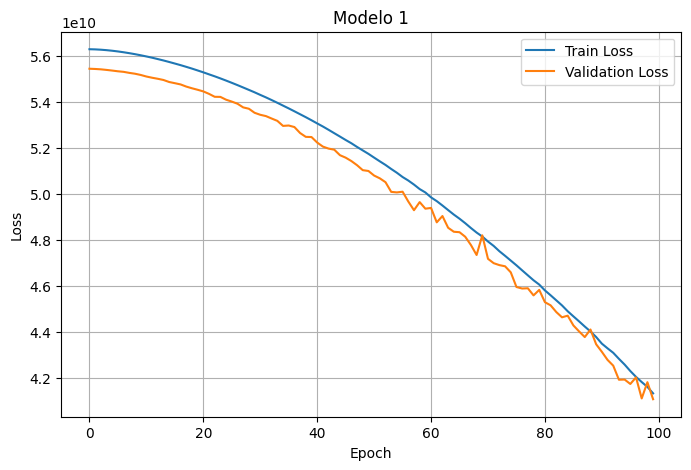

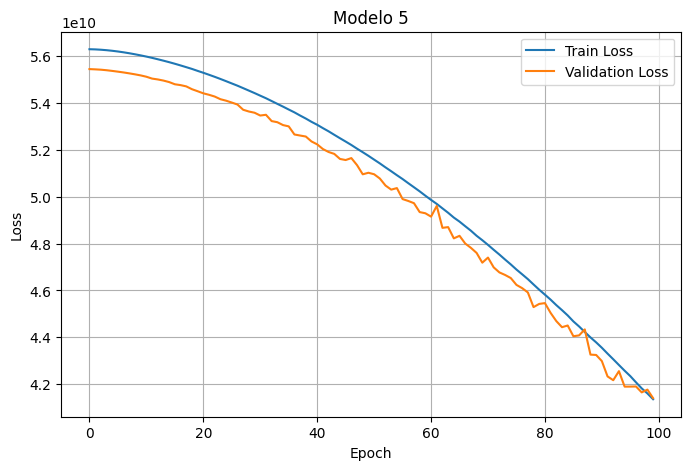

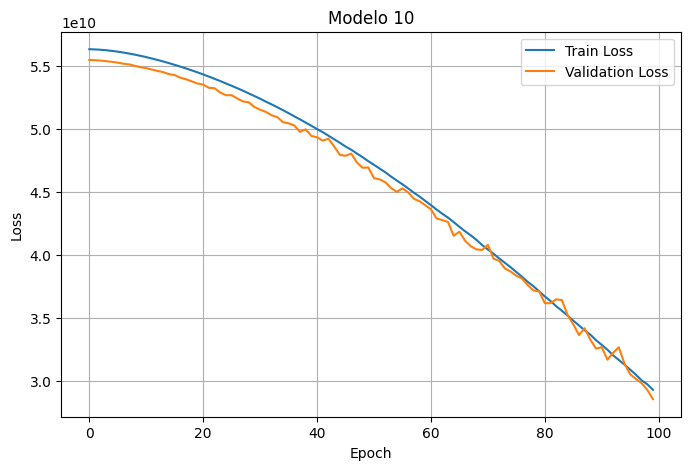

In [68]:
plot_losses(results[0], 1)
plot_losses(results[4], 5)

best_idx = results_df.index[0]
plot_losses(results[best_idx], best_idx + 1)

### Evaluar el mmejor modelo en el conjunto de prueba

In [69]:
test_loader = DataLoader(
    test_dataset,
    batch_size=best_config["batch_size"],
    shuffle=False
)

In [70]:
best_model.eval()

predictions = []
targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = best_model(X_batch)

        predictions.extend(outputs.cpu().numpy())

        targets.extend(y_batch.cpu().numpy())

predictions = np.array(predictions)
targets = np.array(targets)

test_mse = mean_squared_error(targets, predictions)
test_mae = mean_absolute_error(targets, predictions)
test_rmse = np.sqrt(test_mse)

print(f"MSE: {test_mse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")

MSE: 28696733696.0000
MAE: 149476.3125
RMSE: 169401.1030
